In [1]:
import pandas as pd
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
from scipy import stats



2025-02-14 15:55:18.141870: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-14 15:55:18.146610: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-14 15:55:18.187863: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-14 15:55:18.239525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-14 15:55:18.291248: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

# Compleate pipeline



## Data
We used reCombat for RNAseq and microarray independently one form another.

In [2]:
rnaSeq_origial =  pd.read_csv("/home/karen/Documents/GitHub/batch_correction/Results/RNAseq_abundances_adjusted_combat_inmose.csv")


/tmp/ipykernel_223795/2143179861.py:1: DtypeWarning: Columns (34508) have mixed types. Specify dtype option on import or set low_memory=False.
  rnaSeq_origial =  pd.read_csv("/home/karen/Documents/GitHub/batch_correction/Results/RNAseq_abundances_adjusted_combat_inmose.csv")


In [ ]:
#seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
#seq_metadata = pd.read_csv(seq_metadata_path)
#rnaSeq_origial= pd.merge(rnaSeq_origial, seq_metadata, on='Sample', how='inner')


In [3]:
rnaSeq_origial.columns

Index(['Sample', 'ENSG00000000003.14', 'ENSG00000000005.5',
       'ENSG00000000419.12', 'ENSG00000000457.13', 'ENSG00000000460.16',
       'ENSG00000000938.12', 'ENSG00000000971.15', 'ENSG00000001036.13',
       'ENSG00000001084.11',
       ...
       'ENSG00000285476.1', 'ENSG00000285480.1', 'ENSG00000285491.1',
       'ENSG00000285505.1', 'ENSG00000285508.1', 'ENSG00000285509.1', 'Age',
       'Experiment', 'Sex', 'Status'],
      dtype='object', length=34510)

### Filter by the genes

In [4]:


rnaSeq_filteres = rnaSeq_origial
del rnaSeq_origial

### Separate test and train datasets

Here I will use prefix seq to say RNAse and arr to say microarray. I am using a test_size of 50 because I will use smote to increase the data for the training.

In [5]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = m.divide_test_train_dataset(rnaSeq_filteres, test_size=0.4)


In [6]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
seq_X_train = pd.DataFrame(scaler.fit_transform(seq_X_train), columns=seq_X_train.columns, index=seq_X_train.index)
with open('scaler_raw_counts.pkl', 'wb') as file:
    pickle.dump(scaler, file)
seq_X_test = pd.DataFrame(scaler.transform(seq_X_test), columns=seq_X_test.columns, index=seq_X_test.index)


In [7]:
# save seq_X_train, seq_y_train,  
seq_train = pd.concat([seq_X_train, seq_y_train, seq_z_train], axis=1)
seq_train.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Train_set.csv", index=False)

# save seq_X_test, seq_y_test,  seq_z_test
seq_test = pd.concat([seq_X_test, seq_y_test, seq_z_test], axis=1)
seq_test.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Test_set.csv", index=False)

### Divide the ages into bins

In [8]:
seq_age_ranges = divide.get_age_distribution(seq_y_train, age_ranges=[18, 26, 35, 70,72,  95])


In [9]:
seq_categories = [18, 26, 35, 70, 72, 95]





In [10]:
seq_y_train_cat = seq_y_train.apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

### Balanced the data using smote

In [11]:
dataset = pd.DataFrame(seq_X_train)
dataset["Age"] = seq_y_train_cat
result = divide.get_feature_SMOTE(dataset, is_categorical=True)
seq_X_train_cat_a = pd.DataFrame(result[0])
seq_y_train_cat_a = result[1]

Class distribution before SMOTE: Counter({'70-72': 40, '35-70': 36, '72-95': 31, '26-35': 29, '18-26': 26})
Class distribution after SMOTE: Counter({'72-95': 40, '70-72': 40, '35-70': 40, '18-26': 40, '26-35': 40})


In [12]:
seq_train_smote = pd.concat([seq_X_train_cat_a, seq_y_train_cat_a], axis=1)
seq_train_smote.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Train_set_SMOTE.csv", index=False)



#### Add noise to the data

In [13]:
noise = np.random.normal(0.01, 0.01, seq_X_train_cat_a.shape)  # Generate random noise with mean 0 and standard deviation 1
#seq_X_train_cat_a = seq_X_train_cat_a + noise


In [14]:

seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)


In [15]:
seq_train_smote_noise = pd.concat([seq_X_train_cat_a, seq_y_train_a], axis=1)
seq_train_smote_noise.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_inmose_z_score_Train_set_SMOTE_noise.csv", index=False)

### Normalizing the data

### Preparing the model

Before running the model, we look for the best parameter

First we define the optimization function like the following

In [16]:
from optuna.samplers import TPESampler
gamma_value = 0.1  

class Optimize:
    def __init__(self, train_data, n_trials=50, initial_params=None):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=0.07)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
        self.initial_params = initial_params

    def optimize(self):
        study = optuna.create_study(direction='minimize')#, sampler=TPESampler(gamma=gamma_value))

        # Enqueue initial parameters
        if self.initial_params:
            study.enqueue_trial(self.initial_params)

        # Run optimization
        study.optimize(self.objective, n_trials=self.n_trials)

        # Save best parameters
        self.best_params = study.best_params
        print("Best Parameters:", self.best_params)
        return self.best_params

    def objective(self, trial):
        # Define hyperparameters
        params = {
            'iterations': trial.suggest_int('iterations', 50, 100),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
            'depth': trial.suggest_int('depth', 2, 5),
            'verbose': 0,
            'od_type': 'Iter',
            'od_wait': 5,
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 5.0),
            'random_strength': trial.suggest_float('random_strength', 1, 5),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 30, 60),
            'score_function': 'L2',
            'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),
            'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 0.2),
            'eval_metric': 'RMSE'
        }

        # Train model
        regressor = CatBoostRegressor(**params)
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)

        # Evaluate
        y_pred = regressor.predict(self.X_test)
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        if rmse > 20:  
            raise optuna.TrialPruned()
        
        return rmse

In [17]:
fit= True

In [18]:
initial_param = {'iterations': 100, 'learning_rate': 0.09592953486830108, 'depth': 5, 'l2_leaf_reg': 0.6239128213222185, 'random_strength': 4.120487960280333, 'min_data_in_leaf': 69, 'score_function': 'L2', 'penalties_coefficient': 7.023486406525698, 'model_shrink_rate': 0.0006569162178704487} # Best is trial 22 with value: 10.490825934217996


In [21]:
seq_train_smote_noise

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.729849,-0.280814,-0.623426,-0.252232,-0.426722,-0.191819,-0.684505,-0.661289,-0.489146,-0.241932,...,-0.204519,-0.169743,-0.174483,-0.175907,0.004524,-0.147739,-0.301468,-0.351086,-0.286911,80.0
1,-0.527720,4.977168,-0.307356,0.180546,0.353721,-0.167281,0.798796,0.589891,0.051547,0.233188,...,-0.204519,0.010056,0.128873,8.957305,-0.223310,-0.147739,1.972508,-0.352007,-0.114869,70.0
2,0.674875,-0.280814,0.107610,-0.252232,-0.467965,-0.189661,0.783655,-0.278252,0.144045,-0.214800,...,-0.204519,-0.101448,0.517625,-0.175907,-0.252466,-0.147739,-0.301468,-0.269062,0.149249,51.0
3,-0.695175,1.092362,-0.606680,-0.252232,-0.402512,-0.191819,-0.648955,-0.585911,-0.554301,-0.278262,...,-0.204519,-0.169743,-0.174483,-0.175907,-0.252466,-0.147739,-0.301468,-0.351867,-0.286911,49.0
4,-0.758451,-0.280814,-0.605529,0.067849,-0.552453,3.237814,-0.673841,-0.618033,-0.504501,-0.240432,...,-0.204519,-0.169743,-0.174483,-0.175907,-0.252466,-0.147739,-0.301468,-0.352007,-0.286911,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.772733,-0.280814,-0.605500,-0.252232,-0.552453,-0.191819,-0.671139,-0.595392,-0.515796,-0.250459,...,-0.204519,-0.169743,-0.174483,-0.175907,-0.252466,-0.147739,-0.301468,-0.352007,-0.286911,80.0
196,-0.761497,-0.280814,-0.612795,-0.252232,-0.552453,-0.191819,-0.658533,-0.634659,-0.538277,-0.252894,...,-0.204519,-0.169743,-0.174483,-0.175907,-0.252466,-0.147739,-0.301468,-0.351997,-0.286911,85.0
197,-0.771159,-0.280814,-0.610880,-0.252232,-0.424606,-0.191819,-0.663592,-0.655624,-0.527464,-0.278262,...,-0.204519,-0.169743,-0.174483,-0.175907,-0.235412,-0.147739,-0.301468,-0.345171,-0.286911,85.0
198,0.353549,-0.280814,0.728729,-0.252230,-0.205698,-0.191818,1.190363,0.345512,0.862890,-0.054244,...,-0.204519,-0.037640,0.229810,-0.175907,-0.252044,-0.147739,-0.300215,-0.339313,-0.213238,87.0


In [22]:
if fit:
    optimizer = Optimize(train_data = seq_train_smote_noise, n_trials=50, initial_params=initial_param)
    params = optimizer.optimize()
    params

[I 2025-02-14 16:10:54,873] A new study created in memory with name: no-name-10bd2b96-f764-4db4-9398-ca76c2413712
/tmp/ipykernel_223795/3535472432.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/optuna/trial/_trial.py:652: UserWarning: Fixed parameter 'min_data_in_leaf' with value 69 is out of range for distribution IntDistribution(high=60, log=False, low=30, step=1).
  warnings.warn(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the

Best Parameters: {'iterations': 75, 'learning_rate': 0.1084073926434596, 'depth': 4, 'l2_leaf_reg': 1.2617734799474234, 'random_strength': 1.9728594124341607, 'min_data_in_leaf': 35, 'penalties_coefficient': 3.951322072686899, 'model_shrink_rate': 0.023587032001986696}


In [23]:
{'iterations': 227, 'learning_rate': 0.0028565547845807874, 'depth': 5, 'l2_leaf_reg': 3.8329099901447767, 'random_strength': 5.348304633396987, 'min_data_in_leaf': 42, 'score_function': 'L2', 'penalties_coefficient': 3.466166194526145, 'model_shrink_rate': 0.14097574874565943} #18
{'iterations': 100, 'learning_rate': 0.09592953486830108, 'depth': 5, 'l2_leaf_reg': 0.6239128213222185, 'random_strength': 4.120487960280333, 'min_data_in_leaf': 69, 'score_function': 'L2', 'penalties_coefficient': 7.023486406525698, 'model_shrink_rate': 0.0006569162178704487} # Best is trial 22 with value: 10.490825934217996
{'iterations': 82, 'learning_rate': 0.07860350025587313, 'depth': 4, 'l2_leaf_reg': 2.7753441250952067, 'random_strength': 5.053963274929785, 'min_data_in_leaf': 44, 'score_function': 'L2', 'penalties_coefficient': 5.413022443234976, 'model_shrink_rate': 0.003897119513536284}#. Best is trial 44 with value: 10.981738454999292.
seq_params = {'iterations': 75, 'learning_rate': 0.1084073926434596, 'depth': 4, 'l2_leaf_reg': 1.2617734799474234, 'random_strength': 1.9728594124341607, 'min_data_in_leaf': 35, 'penalties_coefficient': 3.951322072686899, 'model_shrink_rate': 0.023587032001986696}


In [ ]:
seq_parms = {'iterations': 462, 'learning_rate': 0.0510, 'depth': 5}
seq_params = {'iterations': 556, 'learning_rate': 0.008352826387919279, 'depth': 3, 'l2_leaf_reg': 8.625993928282805, 'random_strength': 5.518222301454832, 'min_data_in_leaf': 37, 'score_function': 'L2', 'penalties_coefficient': 0.9978892027428243, 'model_shrink_rate': 0.03029125396360066}




### Train the model
For this, we will take catBoost since is the one that worked the best

#### RNAseq


In [24]:
dataset = pd.DataFrame(seq_X_train_cat_a)
dataset.columns = seq_X_train_cat_a.columns
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=4,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  random_strength=0.7,
                                  ) 
seq_regressor = CatBoostRegressor(**seq_params)

# Fit the model
seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=False)



/tmp/ipykernel_223795/1802402455.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset["Age"] = seq_y_train_a


0:	learn: 23.0299958	test: 23.4033819	best: 23.4033819 (0)	total: 463ms	remaining: 34.3s
1:	learn: 22.4956107	test: 23.1152693	best: 23.1152693 (1)	total: 844ms	remaining: 30.8s
2:	learn: 22.1813773	test: 23.1116395	best: 23.1116395 (2)	total: 1.18s	remaining: 28.4s
3:	learn: 21.3787120	test: 22.5175529	best: 22.5175529 (3)	total: 1.54s	remaining: 27.3s
4:	learn: 20.8542658	test: 22.4424503	best: 22.4424503 (4)	total: 1.84s	remaining: 25.8s
5:	learn: 20.0948767	test: 21.9276348	best: 21.9276348 (5)	total: 2.16s	remaining: 24.9s
6:	learn: 19.7828023	test: 21.6652599	best: 21.6652599 (6)	total: 2.41s	remaining: 23.5s
7:	learn: 19.4503111	test: 21.4144987	best: 21.4144987 (7)	total: 2.65s	remaining: 22.2s
8:	learn: 19.1340846	test: 21.3218869	best: 21.3218869 (8)	total: 2.9s	remaining: 21.2s
9:	learn: 18.9064877	test: 21.2351192	best: 21.2351192 (9)	total: 3.16s	remaining: 20.5s
10:	learn: 18.6829794	test: 21.1783843	best: 21.1783843 (10)	total: 3.47s	remaining: 20.2s
11:	learn: 18.255874

In [25]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse


208.07128776688097

#### Plotting results

We have some pre desing plots for the results.

In [26]:
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

/tmp/ipykernel_223795/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


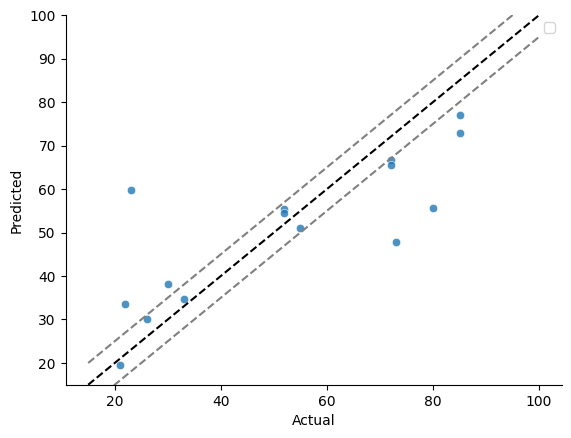

In [27]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

#### Reviewing with original (not augmented) data

In [28]:
seq_X_train_normalize = scaler.transform(seq_X_train)
y_pred = seq_regressor.predict(seq_X_train_normalize)
seq_mse = mean_squared_error(seq_y_train, y_pred)
seq_mse


538.587658874419

     Actual  Predicted Actual_round Predicted_round Experiment
16     73.0  59.290163        72-95           35-70  GSE167186
165    71.0  59.290163        70-72           35-70  GSE157585
145    63.0  59.038736        35-70           35-70  GSE164471
15     69.0  59.290163        35-70           35-70  GSE167186
65     64.0  59.290163        35-70           35-70  GSE167186
..      ...        ...          ...             ...        ...
208    71.0  59.290163        70-72           35-70  GSE157585
140    52.0  60.829186        35-70           35-70  GSE164471
7      88.0  59.290163        72-95           35-70  GSE167186
179    71.0  59.290163        70-72           35-70  GSE157585
12     77.0  59.290163        72-95           35-70  GSE167186

[162 rows x 5 columns]


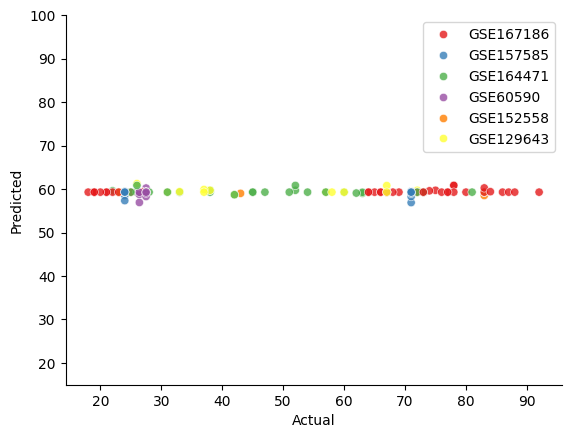

In [29]:

seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
m.plot_results(results=seq_results, labels=seq_z_train)

#### Reviewing with compleatly untouch data

In [30]:
seq_normalize_X_test = scaler.transform(seq_X_test)

print(len(seq_normalize_X_test))

108


In [31]:
y_pred = seq_regressor.predict(seq_normalize_X_test)
len(y_pred)

108

In [32]:

# Evaluate mean squared error
seq_mse = mean_squared_error(seq_y_test, y_pred)
seq_mse

531.0843188429409

In [33]:
rmse = np.sqrt(seq_mse)
mae = np.mean(abs(seq_y_test - y_pred))
r2 = 1 - (np.sum((seq_y_test - y_pred) ** 2) / np.sum((seq_y_test - np.mean(seq_y_test)) ** 2))
print(f"MSE: {seq_mse} \n RMSE: {rmse} \n MAE: {mae} \n R2: {r2}")

MSE: 531.0843188429409 
 RMSE: 23.045266734037618 
 MAE: 20.554248387626824 
 R2: -0.08412432652086


In [34]:
seq_results = pd.DataFrame({'Actual': seq_y_test, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))



In [35]:
seq_z_test

,Sample,Sex,Status,Experiment,Age
97,SRR8882195,female,Healthy,GSE129643,25.0
222,SRR12604216,NaN,Healthy,GSE157585,24.0
224,SRR12604218,NaN,Healthy,GSE157585,24.0
253,SRR1555198,female,trained,GSE60590,26.4
120,SRR13388748,male,Healthy,GSE164471,67.0
...,...,...,...,...,...
48,SRR13759033,male,Healthy,GSE167186,66.0
132,SRR13388760,female,Healthy,GSE164471,31.0
2,SRR13758986,male,Healthy,GSE167186,69.0
57,SRR13759042,male,Healthy,GSE167186,66.0


     Actual  Predicted Actual_round Predicted_round Experiment
97     25.0  59.290163        18-26           35-70  GSE129643
222    24.0  59.396282        18-26           35-70  GSE157585
224    24.0  57.475191        18-26           35-70  GSE157585
253    26.4  60.814027        26-35           35-70   GSE60590
120    67.0  59.263842        35-70           35-70  GSE164471
..      ...        ...          ...             ...        ...
48     66.0  59.290163        35-70           35-70  GSE167186
132    31.0  59.290163        26-35           35-70  GSE164471
2      69.0  59.290163        35-70           35-70  GSE167186
57     66.0  59.290163        35-70           35-70  GSE167186
177    71.0  59.396282        70-72           35-70  GSE157585

[108 rows x 5 columns]


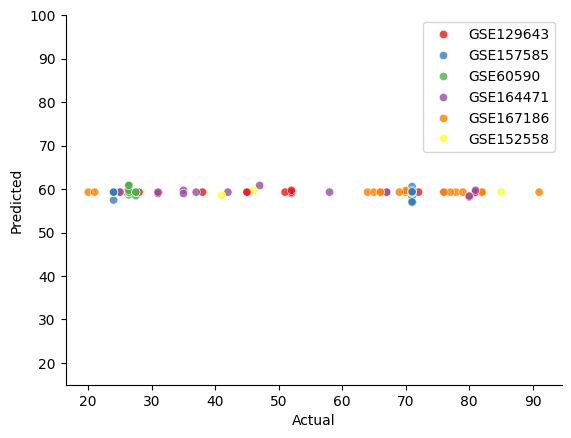

In [36]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [30, 115], color='gray', linestyle='--')
plt.plot([15, 100], [0, 85], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:
# Performace metrics
ROC = accuracy_score(seq_results["Actual_round"], seq_results["Predicted_round"])
MCC = matthews_corrcoef(seq_results["Actual_round"], seq_results["Predicted_round"])
F1 = f1_score(seq_results["Actual_round"], seq_results["Predicted_round"], average='weighted')
print(f"ROC: {ROC} \n MCC: {MCC} \n F1: {F1}") 

In [ ]:
ROC: 0.6851851851851852 
 MCC: 0.6122957120693203 
 F1: 0.6863881972542103

### Feaures

In [ ]:
explainer = shap.Explainer(seq_regressor)
seq_test_df = pd.DataFrame(seq_normalize_X_test)
seq_test_df.columns = seq_X_train_cat_a.columns
seq_test_df["Age"]= seq_y_test
shap_values = explainer.shap_values(seq_test_df)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=seq_X_train_cat_a.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)


In [ ]:
shap.summary_plot(shap_values, seq_test_df, max_display=10)


In [ ]:
feature_imporance_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAseq_z-score_Combat_Smote_shap.csv", index=True)

# Double filter


In [ ]:
filter_genes = feature_imporance_df[feature_imporance_df["importance"] > 0.1].index
filter_genes = filter_genes.to_list()
len(filter_genes)

In [ ]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset = dataset[filter_genes]
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)

y_train = pd.Series(y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Initialize CatBoostClassifier
seq_classifier = CatBoostClassifier(iterations=4000,
                                  learning_rate=0.005,
                                  depth=3,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  ) 

# Fit the model
seq_classifier.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



In [ ]:
y_pred = seq_classifier.predict(X_test)

# Evaluate mean squared error
seq_mcc = matthews_corrcoef(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.T[0]})
seq_mcc

In [ ]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_normalize_X_test_filter = pd.DataFrame(seq_normalize_X_test)
seq_normalize_X_test_filter.columns = rnaseq_genes[:-5]


Source data

 I WAS HERE!!!!!!!!!!!!!!!!!!!!
 The mcc of the source data make no sense, find the error

In [ ]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)




In [ ]:
seq_normalize_X_test_filter = pd.DataFrame(seq_X_train_normalize)
seq_normalize_X_test_filter.columns = rnaseq_genes[:-5]
seq_normalize_X_test_filter= seq_normalize_X_test_filter[filter_genes]
seq_normalize_X_test_filter.shape

In [ ]:
y_pred = seq_classifier.predict(seq_normalize_X_test_filter)

In [ ]:
len(y_pred.T[0])

In [ ]:
seq_y_train.shape

In [ ]:


seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred.T[0]})
seq_y_test_c = pd.Series(seq_y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred.T[0])
seq_mcc

In [ ]:
seq_results

In [ ]:
seq_results_return = seq_results.copy()
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise



In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_train)

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_train, print_label="Status")

In [ ]:
seq_results_return_df = pd.DataFrame(seq_results_return)
seq_results_return_df.merge(seq_z_train)
seq_results_return_df["Status"] = seq_z_train["Status"]
seq_results_return_df["Sample"] = seq_z_train["Sample"]
seq_results_return_df["Sex"] = seq_z_train["Sex"]
seq_results_return_df["Difference"] = abs(seq_results_return_df["Actual"] - seq_results_return_df["Predicted"])
seq_results_return_df = seq_results_return_df.sort_values(by="Difference", ascending=False)
seq_results_return_df[seq_results_return_df["Difference"]>13]

In [ ]:
len(seq_results_return_df[seq_results_return_df["Difference"]>13])/len(seq_results_return_df)

Unseen data

In [ ]:
# Make predictions
X_test_filter = pd.DataFrame(seq_X_test)
X_test_filter.columns = rnaseq_genes[:-5]
X_test_filter = seq_scaler.transform(X_test_filter)
X_test_filter = pd.DataFrame(X_test_filter)
X_test_filter.columns = rnaseq_genes[:-5]
X_test_filter = X_test_filter[filter_genes]


In [ ]:
#normalize_seq_X_test = seq_scaler.transform(seq_X_test)
y_pred = seq_classifier.predict(X_test_filter)
seq_y_test_c = pd.Series(seq_y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Evaluate mean squared error
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred)
seq_results = pd.DataFrame({'Actual': seq_y_test_c, 'Predicted': y_pred.T[0]})
seq_mcc

In [ ]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

In [ ]:

# Evaluate mean squared error
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_results_return = seq_results.copy()
seq_results_return["Actual"]  = seq_y_test
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise
m.plot_results(results=seq_results_return, labels=seq_z_test)

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Status")

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Sex")

In [ ]:
seq_results_return_df = pd.DataFrame(seq_results_return)
seq_results_return_df.merge(seq_z_test)
seq_results_return_df["Status"] = seq_z_test["Status"]
seq_results_return_df["Sample"] = seq_z_test["Sample"]
seq_results_return_df["Sex"] = seq_z_test["Sex"]
seq_results_return_df["Difference"] = abs(seq_results_return_df["Actual"] - seq_results_return_df["Predicted"])
seq_results_return_df = seq_results_return_df.sort_values(by="Difference", ascending=False)
seq_results_return_df[seq_results_return_df["Difference"]>13]

In [ ]:
len(seq_results_return_df[seq_results_return_df["Difference"]>15])/len(seq_results_return_df)